# Receiver Function inversion with noise estimation from a pre-signal window

[![Open In Colab](https://img.shields.io/badge/open%20in-Colab-b5e2fa?logo=googlecolab&style=flat-square&color=ffd670)](https://colab.research.google.com/github/inlab-geo/cofi-examples/blob/main/examples/receiver_function/receiver_function_kernel.ipynb)

> If you are running this notebook locally, make sure you've followed [steps here](https://github.com/inlab-geo/cofi-examples#run-the-examples-with-cofi-locally)
to set up the environment. (This [environment.yml](https://github.com/inlab-geo/cofi-examples/blob/main/envs/environment.yml) file
specifies a list of packages required to run the notebooks)

This notebook demonstrates a **two-step approach** to receiver function inversion that separates noise characterization from model estimation. We first show why the naive approach of jointly estimating model and noise parameters from the full dataset gives poor results, then present the improved method.

1. **Naive approach** (Section 3): Jointly estimate `m` and `eta = log(l)` from all data using `kernel` (profile likelihood). This fails because model misfit contaminates the noise estimates.

2. **Step 1 — Noise estimation** (Section 4): Estimate the noise amplitude `sigma_d` and correlation length `l` from a **pre-signal window** where the forward model response is zero.

3. **Step 2 — Joint inversion** (Section 5): Use the noise estimates as informative Gaussian priors and jointly invert for `m`, `phi = log(sigma_d)`, and `eta = log(l)` using the `kernel_full` case.

## 0. Import modules

In [1]:
# -------------------------------------------------------- #
#                                                          #
#     Uncomment below to set up environment on "colab"     #
#                                                          #
# -------------------------------------------------------- #

# !pip install -U cofi pyrf96

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import cofi
import pyrf96
from cofi.utils import SquaredExponentialKernel, ReducedLikelihood, QuadraticReg

In [3]:
# randomness is used to generate synthetic noisy data
np.random.seed(42)

We use the receiver function package [`pyrf96`](https://github.com/inlab-geo/pyrf96), with calls to Fortran routines developed by Prof. T. Shibutani.

## 1. Generate synthetic data

Define a 4-layer Earth model and generate synthetic receiver function with correlated noise.

In [4]:
# True model: [depth (km), S-velocity (km/s), Vp/Vs]
good_model = np.array([
    [1, 3.0, 1.7],
    [8.0, 3.2, 2.0],
    [20, 4.0, 1.7],
    [45, 4.2, 1.7]
])

In [5]:
# Calculate receiver functions
t, rfunc = pyrf96.rfcalc(good_model)  # Noise-free
t2, rfunc_noise = pyrf96.rfcalc(good_model, sn=0.5, seed=12345678)  # With correlated noise

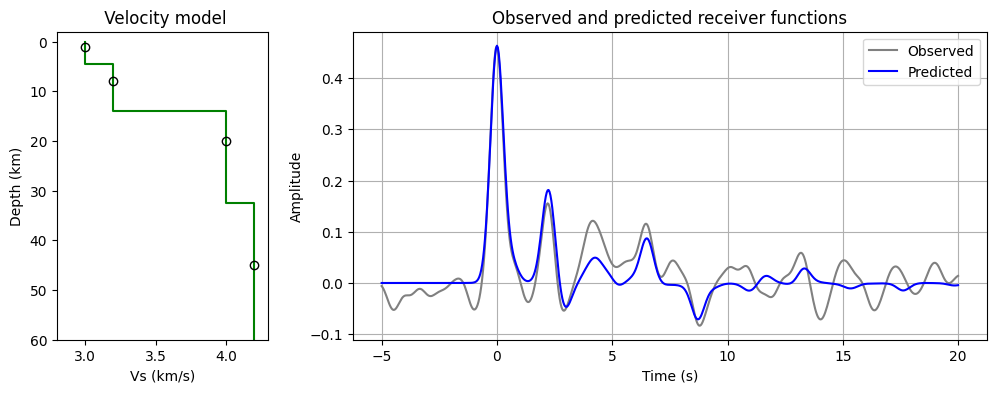

In [6]:
# Plot model and receiver function
a, b = pyrf96.plotRFm(
    good_model, t2, rfunc_noise, t, rfunc,
    vmin=2.8, vmax=4.3, dmin=-2.0, dmax=60.0,
    plotnuclei=True,
    title="Observed and predicted receiver functions"
)

## 2. Model parameterization and forward function

In [7]:
# Fixed Vp/Vs ratios
vpvs = good_model[:, 2]

def get_inversion_parameters(fullmodel):
    """Convert full model to inversion parameters (depths + velocities)."""
    return fullmodel[:, :2].flatten()

def get_model_parameters(invmodel):
    """Convert inversion parameters back to full model."""
    return np.append(invmodel.reshape(len(vpvs), -1), vpvs[:, None], axis=1)

n_m = 8  # number of physical model parameters (4 depths + 4 velocities)

The forward function takes the augmented model vector and extracts only the physical parameters to compute the receiver function.

In [8]:
def forward_rf(model):
    """Forward function: extracts first n_m parameters, returns RF."""
    inv_params = model[:n_m]
    full_model = get_model_parameters(inv_params)
    _, rf = pyrf96.rfcalc(full_model)
    return rf

## 3. Naive approach: joint estimation from all data

As a first attempt, we jointly estimate the Earth model `m` and the log-correlation-length `eta = log(l)` using the `kernel` case. This profiles out `sigma_d` analytically — the noise amplitude is implicitly estimated as the ML value from `a = r^T K^{-1} r` over the **entire** dataset.

In [9]:
# Kernel over full time series
naive_kernel = SquaredExponentialKernel(t2, nugget=1e-10)

# kernel: profiles out sigma_d, estimates [m, eta]
naive_likelihood = ReducedLikelihood(
    data=rfunc_noise,
    forward_func=forward_rf,
    case='kernel',
    kernel=naive_kernel,
    n_params=n_m,
)

# Initial model: [m (8), eta (1)] = 9 parameters
naive_initial_phys = np.array([
    [1.1, 3.0, 1.7],
    [7.0, 3.2, 2.0],
    [18, 4.1, 1.7],
    [40, 4.2, 1.7]
])
naive_initial_inv = get_inversion_parameters(naive_initial_phys)
naive_initial_eta = 0.5  # l ~ 1.65
naive_initial = np.concatenate([naive_initial_inv, [naive_initial_eta]])

def naive_objective(model):
    return -naive_likelihood.log_likelihood(model)

naive_problem = cofi.BaseProblem()
naive_problem.set_objective(naive_objective)
naive_problem.set_initial_model(naive_initial)

naive_options = cofi.InversionOptions()
naive_options.set_tool("scipy.optimize.minimize")
naive_options.set_params(method="Nelder-Mead")

naive_inv = cofi.Inversion(naive_problem, naive_options)
naive_result = naive_inv.run()
naive_result.summary()

Summary for inversion result
SUCCESS
----------------------------
fun: -6481.452658592828
nit: 629
nfev: 1035
status: 0
message: Optimization terminated successfully.
final_simplex: (array([[ 1.95429456,  3.62601383,  8.46752328,  4.03874476, 27.43636262,
         4.95595373, 60.71980807,  7.5765992 , -0.99896647],
       [ 1.95429457,  3.62601377,  8.46752323,  4.03874472, 27.43636272,
         4.95595367, 60.71980623,  7.5765993 , -0.99896646],
       [ 1.95429455,  3.62601386,  8.46752341,  4.03874471, 27.43636251,
         4.9559538 , 60.71980906,  7.57659927, -0.99896648],
       [ 1.95429457,  3.62601379,  8.46752356,  4.03874473, 27.43636247,
         4.95595365, 60.71980547,  7.57659941, -0.99896646],
       [ 1.95429461,  3.62601374,  8.4675231 ,  4.03874474, 27.43636257,
         4.95595378, 60.7198074 ,  7.57659924, -0.99896648],
       [ 1.95429463,  3.6260137 ,  8.467523  ,  4.03874473, 27.43636264,
         4.95595379, 60.71980696,  7.57659927, -0.99896648],
       [ 1.95

In [10]:
# Extract naive results
naive_best = naive_result.model
naive_inv_params = naive_best[:n_m]
naive_eta = naive_best[n_m]
naive_ell = np.exp(naive_eta)
naive_full_model = get_model_parameters(naive_inv_params)

# Get sigma_d from ML covariance
naive_Cd_ml = naive_likelihood.get_ml_cov(naive_best)
naive_sigma_d = np.sqrt(naive_Cd_ml[0, 0])

print("NAIVE APPROACH RESULTS")
print("=" * 50)
print(f"Estimated l = {naive_ell:.4f}  (eta = {naive_eta:.4f})")
print(f"Estimated sigma_d = {naive_sigma_d:.4f}")
print()
print("Best-fit model:")
print(naive_full_model)
print("\nTrue model:")
print(good_model)

NAIVE APPROACH RESULTS
Estimated l = 0.3683  (eta = -0.9990)
Estimated sigma_d = 0.0136

Best-fit model:
[[ 1.95429456  3.62601383  1.7       ]
 [ 8.46752328  4.03874476  2.        ]
 [27.43636262  4.95595373  1.7       ]
 [60.71980807  7.5765992   1.7       ]]

True model:
[[ 1.   3.   1.7]
 [ 8.   3.2  2. ]
 [20.   4.   1.7]
 [45.   4.2  1.7]]


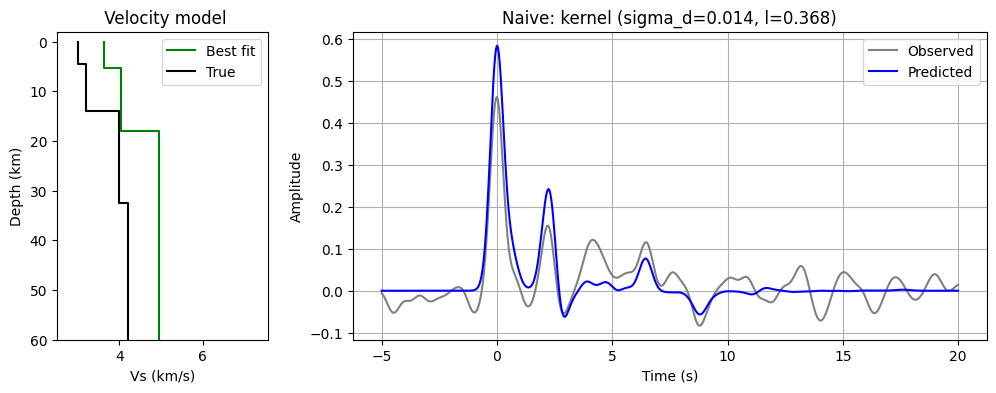

In [11]:
t_naive, rf_naive = pyrf96.rfcalc(naive_full_model)

a, b = pyrf96.plotRFm(
    naive_full_model, t2, rfunc_noise, t_naive, rf_naive,
    vmin=min(good_model[:,1].min(),naive_full_model[:,1].min())-0.5, vmax=max(good_model[:,1].max(),naive_full_model[:,1].max()), dmin=-2.0, dmax=60.0,
    title=f"Naive: kernel (sigma_d={naive_sigma_d:.3f}, l={naive_ell:.3f})",
    velmod2=good_model,
    plotnuclei=False,
    modlabels=['Best fit', 'True']
)

**Why does this fail?** The `kernel` case computes the ML noise amplitude as `sigma_d^2 = r^T K^{-1} r / N` over the entire dataset. Any model misfit (especially in the signal region where the forward model is imperfect) inflates this estimate, which in turn biases the correlation length `l`. The optimizer trades off fitting the data against explaining residuals as correlated noise, leading to poor estimates of both the Earth model and the noise parameters.

To fix this, we estimate noise parameters from a pre-signal window where only noise is present.

## 4. Step 1: Estimate noise parameters from pre-signal window

In the pre-signal window (before the direct P arrival), the receiver function should be zero. Any signal in this window is noise. We use this to estimate the noise correlation length `l` and amplitude `sigma_d` independently of the Earth model.

We use `ReducedLikelihood` with `case='kernel'` and `n_params=0` (no physical parameters), optimizing only over `eta = log(l)`. The noise amplitude `sigma_d` is then obtained from the ML covariance estimate.

In [12]:
# Select pre-signal noise window
t_noise_min, t_noise_max = -5.0, -1
noise_mask = (t2 >= t_noise_min) & (t2 <= t_noise_max)
noise_data = rfunc_noise[noise_mask]
noise_positions = t2[noise_mask]

print(f"Noise window: [{t_noise_min}, {t_noise_max}] s")
print(f"Number of noise samples: {len(noise_data)}")

Noise window: [-5.0, -1] s
Number of noise samples: 101


### 4.1 Optimize eta over the noise window

In [13]:
# Kernel for noise window
noise_kernel = SquaredExponentialKernel(noise_positions, nugget=1e-10)

# Forward model is zero in the noise window
def zero_forward(model_with_eta):
    return np.zeros(len(noise_data))

# ReducedLikelihood for noise-only estimation (n_params=0, no physical model)
noise_likelihood = ReducedLikelihood(
    data=noise_data,
    forward_func=zero_forward,
    case='kernel',
    kernel=noise_kernel,
    n_params=0,
)

# Optimize over eta using bounded scalar optimization
result_noise = minimize_scalar(
    lambda eta: -noise_likelihood.log_likelihood(np.array([eta])),
    bounds=(-2, 3),
    method='bounded',
)

eta_hat = result_noise.x
ell_hat = np.exp(eta_hat)

# Get sigma_d from the ML covariance: Cd_ml = (a/N) * K, so Cd_ml[0,0] = sigma_d^2 * K[0,0]
# Since K[0,0] = 1 for the squared exponential kernel, Cd_ml[0,0] = sigma_d^2
Cd_ml_noise = noise_likelihood.get_ml_cov(np.array([eta_hat]))
sigma_d_hat = np.sqrt(Cd_ml_noise[0, 0])
phi_hat = np.log(sigma_d_hat)

print("Noise window estimates:")
print(f"  eta_hat = {eta_hat:.4f}  =>  l_hat = {ell_hat:.4f}")
print(f"  phi_hat = {phi_hat:.4f}  =>  sigma_d_hat = {sigma_d_hat:.4f}")

Noise window estimates:
  eta_hat = -1.1042  =>  l_hat = 0.3315
  phi_hat = -4.4475  =>  sigma_d_hat = 0.0117


## 5. Step 2: Joint inversion with Gaussian priors

Now we perform a full joint inversion over `[m, phi, eta]` using the `kernel_full` case, where `phi = log(sigma_d)` is kept as an explicit parameter (not profiled out).

The noise-window estimates from Step 1 serve as informative Gaussian priors on `phi` and `eta`, implemented via `QuadraticReg`.

### 5.1 Set up likelihood and priors

In [14]:
# Full kernel over entire time series
kernel = SquaredExponentialKernel(t2, nugget=1e-10)

# Likelihood with explicit sigma_d (kernel_full)
likelihood = ReducedLikelihood(
    data=rfunc_noise,
    forward_func=forward_rf,
    case='kernel_full',
    kernel=kernel,
    n_params=n_m,
)

# Initial physical model (close to truth)
initial_model_phys = np.array([
    [1.1, 3.0, 1.7],
    [7.0, 3.2, 2.0],
    [18, 4.1, 1.7],
    [40, 4.2, 1.7]
])
initial_inv_params = get_inversion_parameters(initial_model_phys)

# Full initial model: [m (8), phi (1), eta (1)] = 10 parameters
initial_model = np.concatenate([initial_inv_params, [phi_hat], [eta_hat]])

# Prior reference: noise-window estimates for phi and eta, initial guess for m
prior_ref = initial_model.copy()

# Prior widths: weak for m, tighter for phi and eta
sigma_prior = np.ones(len(initial_model))
sigma_prior[:n_m] = 10.0   # weak prior on physical model parameters
sigma_prior[n_m] = 0.5     # moderate prior on phi = log(sigma_d)
sigma_prior[n_m + 1] = 0.5 # moderate prior on eta = log(l)

# Weighting matrix: diagonal with 1/sigma_prior
W_prior = np.diag(1.0 / sigma_prior)

prior = QuadraticReg(
    weighting_matrix=W_prior,
    reference_model=prior_ref,
)

print(f"Total parameters: {len(initial_model)}")
print(f"  Physical model: {n_m}")
print(f"  phi (log sigma_d): 1  [prior: phi_hat = {phi_hat:.4f}, sigma = {sigma_prior[n_m]:.1f}]")
print(f"  eta (log l):       1  [prior: eta_hat = {eta_hat:.4f}, sigma = {sigma_prior[n_m+1]:.1f}]")

Total parameters: 10
  Physical model: 8
  phi (log sigma_d): 1  [prior: phi_hat = -4.4475, sigma = 0.5]
  eta (log l):       1  [prior: eta_hat = -1.1042, sigma = 0.5]


### 5.2 Define objective and run inversion

The objective function combines the negative log-likelihood with the Gaussian prior penalty:

$$\text{objective}(m, \phi, \eta) = -\ell(m, \phi, \eta) + \frac{1}{2}\|W(x - x_{\text{ref}})\|_2^2$$

In [15]:
def objective(model):
    return -likelihood.log_likelihood(model) + 0.5 * prior(model)

my_problem = cofi.BaseProblem()
my_problem.set_objective(objective)
my_problem.set_initial_model(initial_model)

my_problem.summary()

Summary for inversion problem: BaseProblem
Model shape: (10,)
---------------------------------------------------------------------
List of functions/properties set by you:
['objective', 'initial_model', 'model_shape']
---------------------------------------------------------------------
List of functions/properties created based on what you have provided:
-- none --
---------------------------------------------------------------------
List of functions/properties that can be further set for the problem:
( not all of these may be relevant to your inversion workflow )
['log_posterior', 'log_posterior_with_blobs', 'log_likelihood', 'log_prior', 'gradient', 'hessian', 'hessian_times_vector', 'residual', 'jacobian', 'jacobian_times_vector', 'data_misfit', 'regularization', 'regularization_matrix', 'forward', 'data', 'data_covariance', 'data_covariance_inv', 'blobs_dtype', 'bounds', 'constraints']


In [16]:
my_options = cofi.InversionOptions()
my_options.set_tool("scipy.optimize.minimize")
my_options.set_params(method="Nelder-Mead")

In [17]:
inv = cofi.Inversion(my_problem, my_options)
result = inv.run()
result.summary()

Summary for inversion result
SUCCESS
----------------------------
fun: -8352.40487177802
nit: 332
nfev: 764
status: 0
message: Optimization terminated successfully.
final_simplex: (array([[ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.87481164, 42.56087406,  4.14537864, -4.56521032, -0.99840967],
       [ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.87481164, 42.56087407,  4.14537864, -4.56521032, -0.99840967],
       [ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.87481164, 42.56087407,  4.14537864, -4.56521032, -0.99840967],
       [ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.87481164, 42.56087406,  4.14537864, -4.56521032, -0.99840967],
       [ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.87481164, 42.56087406,  4.14537864, -4.56521032, -0.99840967],
       [ 1.10727297,  2.94256291,  7.49755149,  3.1113348 , 19.83879801,
         3.

## 6. Results

In [18]:
best_model = result.model
best_inv_params = best_model[:n_m]
best_phi = best_model[n_m]
best_eta = best_model[n_m + 1]
best_sigma_d = np.exp(best_phi)
best_ell = np.exp(best_eta)

best_full_model = get_model_parameters(best_inv_params)

print("=" * 50)
print("NOISE PARAMETER ESTIMATES")
print("=" * 50)
print(f"  Step 1 (noise window):  sigma_d = {sigma_d_hat:.4f},  l = {ell_hat:.4f}")
print(f"  Step 2 (joint inv.):    sigma_d = {best_sigma_d:.4f},  l = {best_ell:.4f}")
print()
print("EARTH MODEL")
print("=" * 50)
print("Best-fit:")
print(best_full_model)
print("\nTrue:")
print(good_model)

NOISE PARAMETER ESTIMATES
  Step 1 (noise window):  sigma_d = 0.0117,  l = 0.3315
  Step 2 (joint inv.):    sigma_d = 0.0104,  l = 0.3685

EARTH MODEL
Best-fit:
[[ 1.10727297  2.94256291  1.7       ]
 [ 7.49755149  3.1113348   2.        ]
 [19.83879801  3.87481164  1.7       ]
 [42.56087406  4.14537864  1.7       ]]

True:
[[ 1.   3.   1.7]
 [ 8.   3.2  2. ]
 [20.   4.   1.7]
 [45.   4.2  1.7]]


### 6.1 Plot results

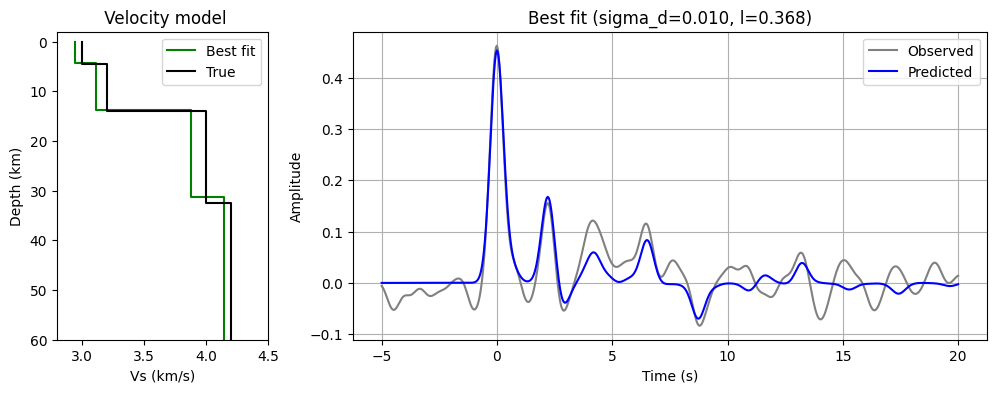

In [19]:
t_pred, rf_pred = pyrf96.rfcalc(best_full_model)

a, b = pyrf96.plotRFm(
    best_full_model, t2, rfunc_noise, t_pred, rf_pred,
    vmin=2.8, vmax=4.5, dmin=-2.0, dmax=60.0,
    title=f"Best fit (sigma_d={best_sigma_d:.3f}, l={best_ell:.3f})",
    velmod2=good_model,
    plotnuclei=False,
    modlabels=['Best fit', 'True']
)

## 7. Discussion

### Two-step approach

1. **Step 1**: Noise parameters (`sigma_d`, `l`) are estimated from the pre-signal window `t = [-5, -1] s` where the forward model is zero. This avoids contaminating noise estimates with model misfit.

2. **Step 2**: These estimates serve as Gaussian priors in a joint inversion over `[m, phi, eta]` using the full dataset. The `kernel_full` case keeps `sigma_d` as an explicit parameter (via `phi = log(sigma_d)`), unlike the `kernel` case which profiles it out analytically.

### Comparison to naive and fixed-noise approaches

- **Naive approach** (Section 3): Joint estimation of `[m, eta]` from full data using `kernel`. Model misfit inflates `sigma_d` and biases `l`.
- **Fixed-noise approach** (original notebook): `Cdinv = pyrf96.InvDataCov(2.5, 0.01, n)` with arbitrarily **fixed** noise parameters.
- **Two-step approach** (Sections 4-5): Noise parameters **estimated from pre-signal window**, then refined jointly with the Earth model using informative priors.

---
## Watermark

In [20]:
watermark_list = ["cofi", "numpy", "matplotlib", "scipy"]
for pkg in watermark_list:
    pkg_var = __import__(pkg)
    print(pkg, getattr(pkg_var, "__version__"))

cofi 0.2.11+52.gbe767ff
numpy 2.3.5
matplotlib 3.10.8
scipy 1.17.0
